# Technical Lesson The Data Engineering Lifecycle with Python

### Introduction

Imagine you're working for an agricultural technology company that's developing a smart monitoring system for large-scale farms. The system uses various sensors to collect data about soil moisture, temperature, and sunlight exposure across different areas of a farm. This data is crucial for optimizing irrigation, predicting crop health, and maximizing yield.

For this lesson, we'll simulate the data collection from these sensors and go through the data engineering lifecycle, including data generation, storage, ingestion, transformation, and serving.

### Step 1: Generation

We will 'simulate' data here using numpy to generate random integer values representing sensor readings as data. Numpy can be used to generate a plethora of random data distributions that are incredibly important in running statistical tests and simulations.

This 'sensor' data is being directly read in from the sensor's systems into the organization's data environment and needs to be properly handled via the Data Engineering lifecycle:
- Sensor data is pre-normalized to a scale of 0 to 1 as part of the sensors software
- Three columns of data collected as well as timestamp of collection
    - Moisture
    - Temperature
    - Sunlight
- Erroneous values have been introduced to simulate failed sensor readings (missing data)

Note: Setting a random seed via numpy allows the 'random' generation to be the same each time we run the code and for everyone, allowing for consistency and repetition.


In [1]:
# Imports 
import pandas as pd
import numpy as np

# Set random seed
np.random.seed(42)

# Simulate data generation (sensor readings)
sensor_data = np.random.uniform(0, 1, (100, 3))
sensor_df = pd.DataFrame(sensor_data, columns=['moisture', 'temperature', 'sunlight'])

# Simulate timestamp data
sensor_df['timestamp'] = pd.date_range(start="2024-01-01", end="2024-04-09")

# Introduce values to simulate failed reading
sensor_df.loc[11:16, 'moisture'] = 999
sensor_df.loc[55:60, 'temperature'] = 999

sensor_df

,moisture,temperature,sunlight,timestamp
0,0.374540,0.950714,0.731994,2024-01-01
1,0.598658,0.156019,0.155995,2024-01-02
2,0.058084,0.866176,0.601115,2024-01-03
3,0.708073,0.020584,0.969910,2024-01-04
4,0.832443,0.212339,0.181825,2024-01-05
...,...,...,...,...
95,0.035942,0.465598,0.542645,2024-04-05
96,0.286541,0.590833,0.030500,2024-04-06
97,0.037348,0.822601,0.360191,2024-04-07
98,0.127061,0.522243,0.769994,2024-04-08


### Step 2: Storage

There are a plethora of ways data can be stored, we have previously explored the concept of relational databases via SQL for instance. Here we will utilize simple local storage perhaps representing the saving of this generated data to an in-house server system. We will use pandas to store the generated data locally on our computers as a CSV file.

In [2]:
# Simulate data storage (in-memory storage - hard drive)
sensor_df.to_csv('sensor_data.csv', index=False)

# Sanity Check for file
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


### Step 3: Ingestion

While for this notebook this step might be redundant in that we already have the data loaded in, it's important to make the distinction between 'raw' data (our original sensor readings) and data that is ingested in order to undergo processing, transformation, and ultimately analysis. We want to ensure a copy of the data is being acted upon to prevent saving over the raw data in case it is needed later. 

Hence we will reload the data using pandas so we have 'fresh' copy/variable to act upon. This variable can then be used for further steps without affecting the original data and stored file.

In [3]:
# Load data from stored file
sensor_ingest = pd.read_csv('sensor_data.csv', parse_dates=['timestamp'])
sensor_ingest

,moisture,temperature,sunlight,timestamp
0,0.374540,0.950714,0.731994,2024-01-01
1,0.598658,0.156019,0.155995,2024-01-02
2,0.058084,0.866176,0.601115,2024-01-03
3,0.708073,0.020584,0.969910,2024-01-04
4,0.832443,0.212339,0.181825,2024-01-05
...,...,...,...,...
95,0.035942,0.465598,0.542645,2024-04-05
96,0.286541,0.590833,0.030500,2024-04-06
97,0.037348,0.822601,0.360191,2024-04-07
98,0.127061,0.522243,0.769994,2024-04-08


### Step 4: Transformation

Transformations can involve a wide range of data actions including handling null and duplicate values, the processing of data during ingestion and storage in order to help normalize and standardize data, and the actual data analysis being performed.

In [4]:
# Look for null values
sensor_ingest.isna().sum()

moisture       0
temperature    0
sunlight       0
timestamp      0
dtype: int64

Amazing! Looks like there is definitely no missing data at all and we can proceed without any worry right? Not quite true. It turns out that 'missing' data in this case is represented not as null values but instead as a particular unique value due to how the sensor handles failed readings. 

This is quite common in real world data in fact. You might see missing data represented as a dash '-' or empty white space " ", or some extreme value that would otherwise not be possible given the context of the data.

In our case the simulated sensor data returns 999 for any instance of a failed reading. Given that the sensor's readings are normalized to a scale of 0 to 1, this erroneous value of 999 stands out as a clear indicator. Often times these values can be easily identified by looking at the distributions of your data.

In [5]:
# Identify 'missing' data via statistical distribution
sensor_ingest.describe()

,moisture,temperature,sunlight,timestamp
count,100.000000,100.000000,100.000000,100
mean,60.387477,60.425978,0.496303,2024-02-19 12:00:00
min,0.005522,0.005062,0.006952,2024-01-01 00:00:00
25%,0.243455,0.278538,0.237540,2024-01-25 18:00:00
50%,0.506713,0.583869,0.522412,2024-02-19 12:00:00
75%,0.800581,0.832133,0.712545,2024-03-15 06:00:00
max,999.000000,999.000000,0.969910,2024-04-09 00:00:00
std,238.331112,238.321366,0.288114,NaN


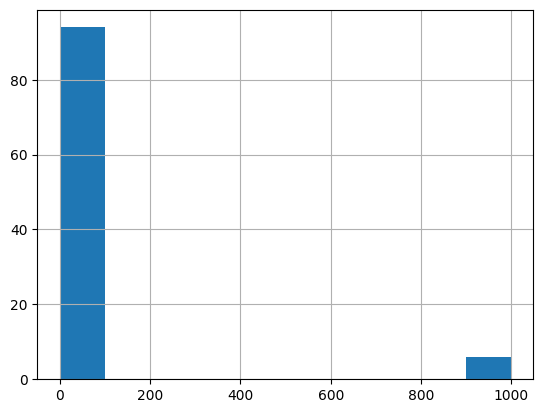

In [6]:
# Visual for distribution
sensor_ingest['moisture'].hist();

In [7]:
# Value counts
sensor_ingest['moisture'].value_counts()

moisture
999.000000    6
0.374540      1
0.349210      1
0.093675      1
0.849223      1
             ..
0.249292      1
0.314356      1
0.107891      1
0.522733      1
0.215821      1
Name: count, Length: 95, dtype: int64

We will go ahead and perform some data transformations to handle these 'missing' sensor readings that have been inputted as 999. For simplicity we will use pandas to foward fill in these values. This will propagate the last valid value forward.
- First we need to transform any values of 999 into appropriate null data type
- Can then use pandas .fillna() method

In [8]:
# Need to first transform any values of 999
sensor_ingest = sensor_ingest.replace({999: np.nan})
sensor_ingest.isna().sum()

moisture       6
temperature    6
sunlight       0
timestamp      0
dtype: int64

In [9]:
# Can now forward fill in null values
sensor_ingest = sensor_ingest.ffill()
sensor_ingest.isna().sum()

moisture       0
temperature    0
sunlight       0
timestamp      0
dtype: int64

In [10]:
# Can now get a better idea of descriptive statistics
sensor_ingest.describe()

,moisture,temperature,sunlight,timestamp
count,100.000000,100.000000,100.000000,100
mean,0.483929,0.518124,0.496303,2024-02-19 12:00:00
min,0.005522,0.005062,0.006952,2024-01-01 00:00:00
25%,0.243455,0.278538,0.237540,2024-01-25 18:00:00
50%,0.506713,0.535775,0.522412,2024-02-19 12:00:00
75%,0.703881,0.774152,0.712545,2024-03-15 06:00:00
max,0.990054,0.985650,0.969910,2024-04-09 00:00:00
std,0.278957,0.302030,0.288114,NaN


### Step 5: Serving

We can now consider two important factors for data serving, the who and the how. It is vital to understand who will be using the data in question and for what purpose it is being used for. These two factors will help determine how you need to 'serve' the data to the end user. 

There are big differences in considerations when the end user is internal to the company or external (third party or customer) including major security concerns as well as cost concerns. Does this produced data need to be stored and persisted or can it exist only when it is needed? If third parties are accessing this data there needs to be a system in place for them to make requests and it should be sequestered from sensitive internal company data.

Our transformed and processed data, with null values handled, can be saved as its own local file to share with the appropriate parties for further use and analysis.

In [11]:
# Save data to file
sensor_ingest.to_csv('cleaned_sensor_data.csv', index=False)
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.
